# Cascaded S-Matrix: Multiple Layers of PEC Cylinders

Same cascade approach as the dielectric version, but with PEC cylinders ($\varepsilon = -1$).

**What this example demonstrates:**
1. PEC has no evanescent modes, so no truncation is needed before cascading
2. Unitarity is preserved through the cascade (PEC is lossless)
3. Transmission drops rapidly with layer count due to strong PEC scattering

In [4]:
import os
os.environ["JAX_ENABLE_X64"] = "1"
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd, norm

sys.path.insert(0, '../..')

from Scattering_Code.smatrix_parameters import smatrix_parameters
from Scattering_Code.jax.smatrix import smatrix
from Scattering_Code.cascadertwo import cascadertwo

In [5]:
WAVELENGTH = 0.93
PERIOD     = 12.81
RADIUS     = 0.25
MU         = 1.0
CMMAX      = 5
PHIINC     = np.pi / 2
NUM_CYL    = 10
SEED       = 42

nmax = int(np.floor(PERIOD / WAVELENGTH))  # PEC: propagating only
nm   = 2 * nmax + 1
print(f"nmax = {nmax}, S-matrix size: {2*nm} x {2*nm}")

nmax = 13, S-matrix size: 54 x 54


## 1. Compute Single-Layer S-Matrix

In [6]:
spacing = 2.5 * RADIUS
cyls_per_row = int(PERIOD / spacing)
rows_needed = NUM_CYL / cyls_per_row + 2
thickness = round(max(0.5, rows_needed * spacing * 1.5), 1)

rng = np.random.RandomState(SEED)
margin = RADIUS * 1.5
min_sep = 2.5 * RADIUS
clocs = np.zeros((NUM_CYL, 2))
for i in range(NUM_CYL):
    for _ in range(10000):
        x = margin + rng.rand() * (PERIOD - 2*margin)
        y = margin + rng.rand() * (thickness - 2*margin)
        if i == 0 or np.all(np.sqrt((x - clocs[:i, 0])**2 + (y - clocs[:i, 1])**2) > min_sep):
            clocs[i] = [x, y]
            break

sp = smatrix_parameters(WAVELENGTH, PERIOD, PHIINC,
                        1e-11, 1e-4, 5, 3, 1000, 3, 5, 1, PERIOD/120)
cmmaxs = np.full(NUM_CYL, CMMAX, dtype=int)
cepmus = np.column_stack([np.full(NUM_CYL, -1.0), np.full(NUM_CYL, MU)])
crads  = np.full(NUM_CYL, RADIUS)

print(f"Computing single-layer PEC S-matrix...")
t0 = time.time()
S_single, _ = smatrix(clocs, cmmaxs, cepmus, crads, PERIOD, WAVELENGTH,
                       nmax, thickness, sp, 'On')
S_single = np.array(S_single)
print(f"Done in {time.time()-t0:.1f}s")

# Unitarity check
S11 = S_single[:nm, :nm]
S21 = S_single[nm:, :nm]
unit_err = norm(S11.conj().T @ S11 + S21.conj().T @ S21 - np.eye(nm))
print(f"Single-layer unitarity error: {unit_err:.2e}")

Computing single-layer PEC S-matrix...
  Computing T-Matrix...


W0417 23:21:43.625609 12420977 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


  transall: 45 pairs (43 spectral, 2 spatial)
  T-Matrix: 11.2s
  Solving linear system...
  Solve: 1.2s
  Computing S11 & S21...
  S11&S21: 0.8s
  Computing S12 & S22...
  S12&S22: 0.1s
  Total: 13.8s (0.2 min)
Done in 17.3s
Single-layer unitarity error: 1.11e-01


## 2. Cascade for 2, 10, 20 Layers

2 layers: max(tau^2)=1.001673, sum(tau^2)=12.3131, unitarity err=1.46e-01
10 layers: max(tau^2)=1.052865, sum(tau^2)=5.8102, unitarity err=2.57e-01
20 layers: max(tau^2)=1.149892, sum(tau^2)=5.4587, unitarity err=3.21e-01


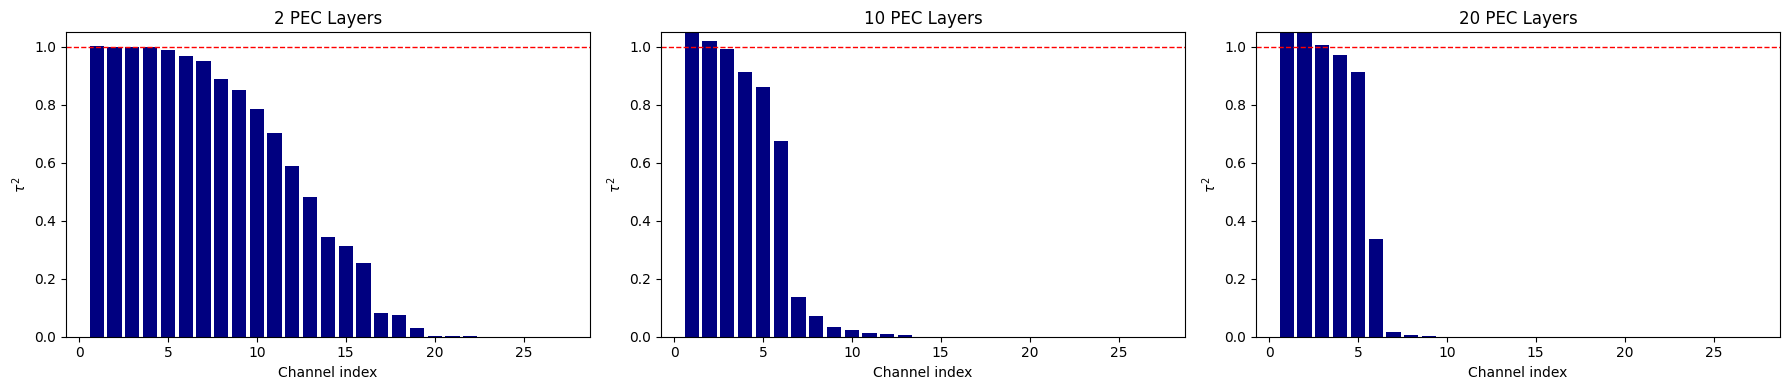

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for idx, n_layers in enumerate([2, 10, 20]):
    S_cas = S_single.copy()
    d_cas = thickness
    for _ in range(1, n_layers):
        S_cas, d_cas = cascadertwo(S_cas, d_cas, S_single, thickness)
    
    # Unitarity check
    S11_c = S_cas[:nm, :nm]
    S21_c = S_cas[nm:, :nm]
    unit_err = norm(S11_c.conj().T @ S11_c + S21_c.conj().T @ S21_c - np.eye(nm))
    
    # Transmission eigenvalues
    tau = svd(S21_c, compute_uv=False)
    
    print(f"{n_layers} layers: max(tau^2)={np.max(tau**2):.6f}, "
          f"sum(tau^2)={np.sum(tau**2):.4f}, unitarity err={unit_err:.2e}")
    
    ax = axes[idx]
    ax.bar(range(1, len(tau)+1), tau**2, color='navy')
    ax.axhline(1.0, color='red', ls='--', lw=1)
    ax.set_xlabel('Channel index')
    ax.set_ylabel(r'$\tau^2$')
    ax.set_title(f'{n_layers} PEC Layers')
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('pec_cascaded_singular_values.png', dpi=150)
plt.show()